In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from astropy.table import Table
import pickle
import pandas as pd
import SyntheticData as sd
import Sampler
import json

/home/bepennell/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
mdwarfs = Table.read('./data/200pc_mdwarfs_reduced.fits', format='fits')
all_mdwarfs = []
relevant_list = ["parallax", "mass", "solution_type"]
for row in tqdm(mdwarfs): # we don't need every object, really 
    df = dict()
    for item in relevant_list:
        working_item = item
        if item == "mass":
            working_item = "mass_single"
        df[item] = float(row[working_item])
    all_mdwarfs.append(df)

  0%|          | 0/225536 [00:00<?, ?it/s]

In [8]:
data_ci = pickle.load(open("./massive_data/2026-01-20-circular.pkl", "rb"))["data"]
data_tu = np.random.choice(pickle.load(open("./massive_data/2026-01-20-reference.pkl", "rb"))["data"], 50000)
data_th = pickle.load(open("./massive_data/2026-01-20-thermal.pkl", "rb"))["data"]
synthdatasets = [data_ci, data_tu, data_th]

In [11]:
sc_cubes_ci = pickle.load(open("./data/2026-01-16-mdwarf_mbins_3plx_circular.pkl", "rb"))
sc_cubes_tu = pickle.load(open("./data/2026-01-26-mdwarf_mbins_3plx_turnover.pkl", "rb"))
sc_cubes_th = pickle.load(open("./data/2026-01-31-mdwarf_mbins_3plx_thermal.pkl", "rb"))
sc_cube_set = [sc_cubes_ci, sc_cubes_tu, sc_cubes_th]

In [12]:
p_model = (4, 1.3)
binary_fraction = 0.3
q_model = 0.5
labels = ["circular", "turnover", "thermal"]

res = np.zeros((len(synthdatasets), len(sc_cube_set), 2, 1000))
res_est = np.zeros((len(synthdatasets), len(sc_cube_set), 3))

#fig, axs = plt.subplots(3,3, figsize=(13,9))

pbar = tqdm(total=len(sc_cube_set)*len(synthdatasets))
for i, sc_cubes in enumerate(sc_cube_set):
    for j in range(len(synthdatasets)):
        #ax = axs[i,j]
        synthdata = synthdatasets[j]
        indices = [0,5,7,9,12]
        working_catalogue = []
        relevant_list = ["parallax", "mass", "solution_type"]
        masses = np.array([row["mass"] for row in all_mdwarfs])
        percs = np.percentile(masses, np.arange(0, 110, 10))
        relevant_list = ["parallax", "mass", "solution_type"]
        for row in np.random.choice(synthdata, len(synthdata)//2):
            df = dict()
            df["soltype_index"] = indices.index(row["solution_type"])   
            df["mass_index"] = np.minimum(np.digitize(row["mass"], percs) - 1, 9)
            for item in relevant_list:
                df[item] = float(row[item])
            working_catalogue.append(df)
        model_cube = Sampler.create_model_cube((35,25), p_model, q_model=q_model)
        synthsampler = Sampler.popsampler(sc_cubes, working_catalogue, model_cube=model_cube)
        res[i,j] = synthsampler.binarity(resolution=1000, catalogue=working_catalogue, scale=3, mass_binned=True, verbose=False)
        mle, p, m = synthsampler.fb_estimator()
        res_est[i,j] = [mle, p, m]
        # ax.plot(synthsampler.fbs, synthsampler.likelihoods, c="black", linewidth=3);
        # ax.axvline(x=mle, c="red", linestyle="--", label=r'FIT: ${:.3f}^{{+{:.3f}}}_{{-{:.3f}}}$'.format(mle,p,m));
        # ax.axvline(x=binary_fraction, c="green", linestyle="--", label=f"TRUTH: {binary_fraction}")
        # ax.set_xlabel("binary fraction");
        # ax.set_ylabel("log-likelihood");
        # ax.set_title(f"data:{labels[j]}, model:{labels[i]}")
        # ax.legend();
        pbar.update(1)
plt.tight_layout()

  0%|          | 0/9 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

In [13]:
outdata = dict()
outdata["data"] = dict()
outdata["data"] = [res, res_est]

outfile = open('./plot_data/eccentricity_test.pkl', "wb")
pickle.dump(outdata, outfile)
outfile.close()

### Make plot

In [14]:
import style

In [15]:
res, res_est = pickle.load(open("./plot_data/eccentricity_test.pkl", "rb"))["data"]

In [16]:
binary_fraction = 0.3

In [17]:
sigmas = np.zeros((3,3))

fbs = res[0,0,0]
e_models = ["Circular", "Turnover", "Thermal"]
for i in range(3):
    for j in range(3):
        sigmas[i,j] = Sampler.fisher_uncertainty(res[i,j,1])
        
latex_table_grid = "\\begin{tabular}{lccc}\n\\toprule\nData $\\backslash$ Model & (4, 1.3) & (4, 2) & (5, 2) \\\\\n\\midrule\n"
for i, pdata in enumerate(e_models):
    row = f"{pdata} "
    for j, mdata in enumerate(e_models):
        mle_val = res_est[j, i, 0] * 100
        s_val = sigmas[j, i] * 100
        row += f"& ${mle_val:.2f}\!\pm\!{s_val:.2f}\%$ "
    row += "\\\\\n"
    latex_table_grid += row
latex_table_grid += "\\bottomrule\n\\end{tabular}"
print(latex_table_grid)

\begin{tabular}{lccc}
\toprule
Data $\backslash$ Model & (4, 1.3) & (4, 2) & (5, 2) \\
\midrule
Circular & $30.54\!\pm\!0.84\%$ & $31.41\!\pm\!0.87\%$ & $36.98\!\pm\!1.00\%$ \\
Turnover & $28.71\!\pm\!0.82\%$ & $29.87\!\pm\!0.85\%$ & $33.04\!\pm\!0.95\%$ \\
Thermal & $25.74\!\pm\!0.78\%$ & $28.71\!\pm\!0.84\%$ & $32.08\!\pm\!0.94\%$ \\
\bottomrule
\end{tabular}


/tmp/ipykernel_1266227/969656800.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sigmas[i,j] = Sampler.fisher_uncertainty(res[i,j,1])


/tmp/ipykernel_61284/2818814860.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend();
/tmp/ipykernel_61284/2818814860.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=legend_label[:-1])


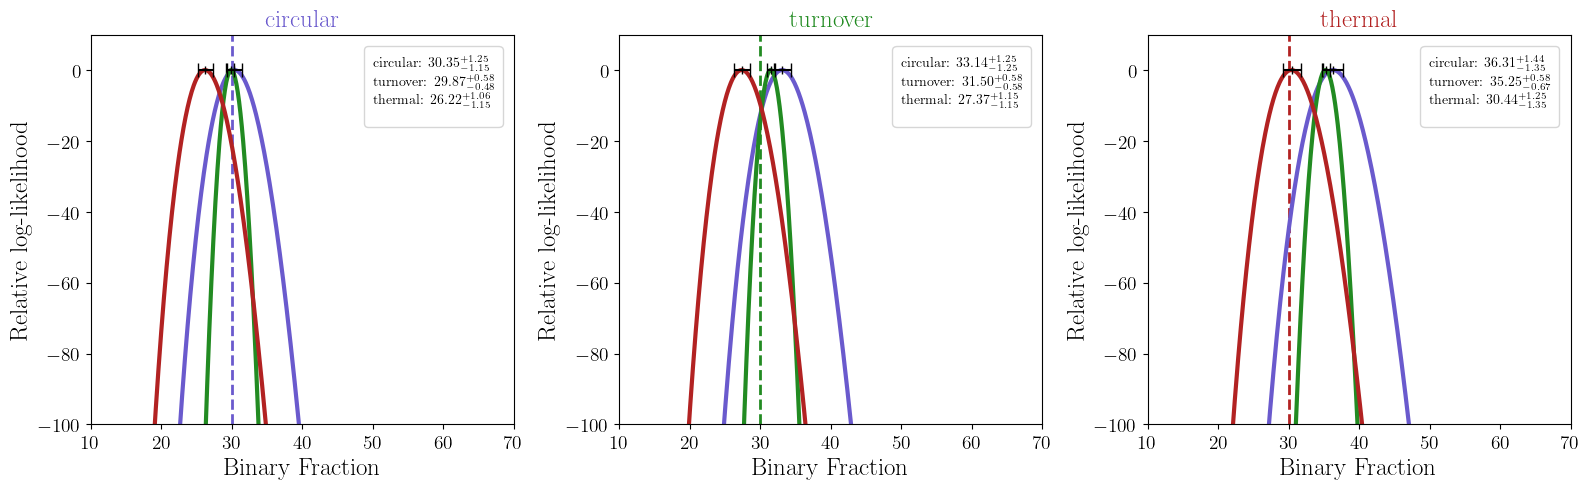

In [33]:
fig, axs = plt.subplots(1,3, figsize=(16,5))
cols = ['slateblue', 'forestgreen', 'firebrick']
labels = ["circular", "turnover", "thermal"]
for i in range(len(labels)):
    ax = axs[i]
    ax.axvline(x=binary_fraction*100, c=cols[i], linestyle="--", linewidth=2);#, label=f"TRUTH: {binary_fraction}")
    ax.legend();
    legend_label = ''
    for j in range(len(synthdatasets)):
        fbs, likelihoods = res[i,j]
        mle, p, m  = res_est[i, j]
        ax.plot(fbs*100, likelihoods-np.max(likelihoods), c=cols[j], linewidth=3);
        legend_label = legend_label + r'{}: ${:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$'.format(labels[j],mle*100,p*100,m*100) + "\n"
        ax.errorbar(mle*100, 0, xerr=([p*100], [m*100]), c="k", marker='|', capsize=5, zorder=2)
        ax.set_xlabel("Binary Fraction");
        ax.set_ylabel("Relative log-likelihood");
        ax.set_title(f"{labels[i]}", color=cols[i])
    ax.legend(title=legend_label[:-1])
    ax.set_ylim(top=10, bottom=-100)
    ax.set_xlim([10,70])
plt.tight_layout()
#plt.savefig("./plots/2026-01-12-period_test.png", dpi=800)

In [34]:
latex_table_grid = "\\begin{tabular}{lccc}\n\\toprule\nData $\\backslash$ Model & Circular & Turnover & Thermal \\\\\n\\midrule\n"
for i, pdata in enumerate(labels):
    row = f"{pdata} "
    for j, mdata in enumerate(labels):
        mle_val = res_est[i, j, 0] * 100
        p_val = res_est[i, j, 1] * 100
        m_val = res_est[i, j, 2] * 100
        row += f"& ${mle_val:.2f}^{{+{p_val:.2f}}}_{{-{m_val:.2f}}}$ "
    row += "\\\\\n"
    latex_table_grid += row
latex_table_grid += "\\bottomrule\n\\end{tabular}"
print(latex_table_grid)

\begin{tabular}{lccc}
\toprule
Data $\backslash$ Model & Circular & Turnover & Thermal \\
\midrule
circular & $30.35^{+1.25}_{-1.15}$ & $29.87^{+0.58}_{-0.48}$ & $26.22^{+1.06}_{-1.15}$ \\
turnover & $33.14^{+1.25}_{-1.25}$ & $31.50^{+0.58}_{-0.58}$ & $27.37^{+1.15}_{-1.15}$ \\
thermal & $36.31^{+1.44}_{-1.35}$ & $35.25^{+0.58}_{-0.67}$ & $30.44^{+1.25}_{-1.35}$ \\
\bottomrule
\end{tabular}


## else

In [3]:
es = np.linspace(0,1,100)
e_pdf = np.zeros(len(es))
e_pdf[1:] = Sampler.pexp(es[1:], 1)
e_cdf = np.cumsum(e_pdf/np.sum(e_pdf))

periods = np.linspace(1,8,100)
turnover_params = (3.5, 1)
pdf = Sampler.gaussian(periods, *turnover_params)
turnover_weight = np.cumsum(pdf/np.sum(pdf))

p_therm = Sampler.pexp(es, 1, val_range=(es[0], es[-1]))
p_therm = p_therm/np.sum(p_therm)
rayleigh_params = (0.38, 0.2)
p_gaus = Sampler.gaussian(es, *rayleigh_params)
p_gaus = p_gaus/np.sum(p_gaus)

def turnover_e(period):
    pcdf_eval = turnover_weight[np.argmin(abs(periods - period))]
    result_dist = (1-pcdf_eval)*p_gaus + pcdf_eval*p_therm
    result_cdf = np.cumsum(result_dist/np.sum(result_dist))
    calc_e = np.interp(np.random.rand(), result_cdf, es)
    return calc_e

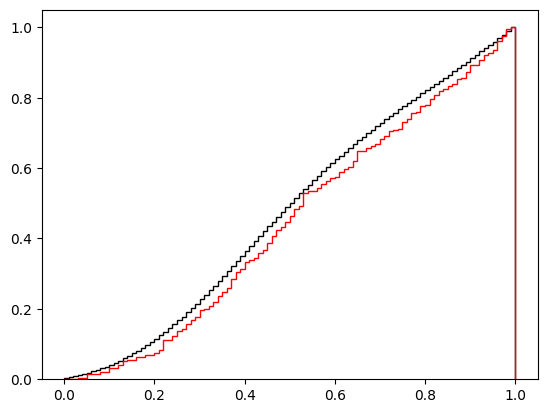

In [18]:
tbins = plt.hist([turnover_e(3.5) for _ in range(100000)], bins=100, cumulative=True, density=True, histtype="step", color="k");
plt.hist([turnover_e(3.5) for _ in range(250)], bins=tbins[1], cumulative=True, density=True, histtype="step", color="r");

In [ ]:
mu, si = period_model
    ps = np.linspace(*p_lim, p_resolution)
    pdf = gaussian(ps, mu, si)
    cdf = np.cumsum(pdf / pdf.sum())
    logP = choose_value(cdf, ps, nb)